# Real-vs-calculated IMF comparison with energy scaling

This notebook reproduces [gd_imf_real_vs_calculated.ipynb](gd_imf_real_vs_calculated.ipynb) but replaces the geometric `a ** (k / 2)` divisor with a stage-specific RMS noise scale.

- **Linear recursive components:** exact finite-sample scale
  $\sigma\sqrt{(\mathcal W_k\mathcal W_k^\top)_{tt}}$, where
  $\mathcal W_k=W_k\prod_{j<k}(I-W_j)$.
- **Linear single-pass errors:** exact scale $\sigma\sqrt{(W_kW_k^\top)_{tt}}$.
- **Robust errors:** parametric-bootstrap estimates of the corresponding RMS scales under the notebook's Gaussian-plus-contamination observation model.

After standardization, an RMSE near one means that the observed component error has approximately the size predicted by its own complete filter. Stage 1 is no longer forced to share the later components' hidden filter-energy constant.

The sup-error panels also use the RMS scale, but they are not expected to be constant: maxima additionally depend on correlation length and effective multiplicity.


## Setup

The signal, observation generator, window schedule, and robust gradient-descent definitions are copied from [gd_irmf.ipynb](../gd-irmf/gd_irmf.ipynb).

In [1]:
import os
import time
from concurrent.futures import ThreadPoolExecutor
from numpy.lib.stride_tricks import sliding_window_view

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


rng = np.random.default_rng(42)

SQRT_2 = np.sqrt(2.0)
SQRT_2_OVER_PI = np.sqrt(2.0 / np.pi)
DEFAULT_MAX_WORKERS = 12

plt.rcParams.update({
    "figure.figsize": (11, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DEFAULT_MAX_WORKERS


12

## Signal, observation, and window schedule

The contaminated observation below is exactly the `p = 0.2` setup from [gd_irmf.ipynb](../gd-irmf/gd_irmf.ipynb). The no-contamination observation is created later with the same seed, Gaussian scale, and contamination scale, but with `contamination_prob = 0.0`.

In [2]:
def odd_ceiling(value):
    size = int(np.ceil(value))
    if size % 2 == 0:
        size += 1
    return max(1, size)


def nearest_odd(value):
    rounded = int(np.round(value))
    if rounded % 2 == 1:
        return max(1, rounded)

    lower = max(1, rounded - 1)
    upper = rounded + 1
    if abs(value - lower) <= abs(upper - value):
        return lower
    return upper


def make_window_schedule(n, factor=np.sqrt(2.0), min_window_size=31):
    if n <= 0:
        raise ValueError("n must be positive")
    if factor <= 1:
        raise ValueError("factor must be larger than 1")

    first = odd_ceiling(n / 2)
    if first > n:
        first = n if n % 2 == 1 else n - 1

    min_size = nearest_odd(min_window_size)
    if min_size > first:
        return [first]

    sizes = [first]
    current = first

    while current > min_size:
        candidate = nearest_odd(current / factor)
        candidate = min(candidate, current - 2)
        if candidate % 2 == 0:
            candidate -= 1
        if candidate < min_size:
            candidate = min_size

        sizes.append(candidate)
        current = candidate

    return sizes


TARGET_SIGNAL_STD = 0.38545431761087123


def gen_signal(t, seed=2026, target_std=TARGET_SIGNAL_STD):
    t = np.asarray(t, dtype=float)
    if t.ndim != 1 or len(t) < 2:
        raise ValueError("t must be a one-dimensional array with at least two points")
    if target_std <= 0:
        raise ValueError("target_std must be positive")

    rng = np.random.default_rng(seed)
    t_span = np.ptp(t)
    if t_span <= 0:
        raise ValueError("t must span a positive interval")
    u = (t - t.min()) / t_span

    def center_and_scale(values, scale):
        values = np.asarray(values, dtype=float) - np.mean(values)
        values_std = np.std(values)
        if values_std == 0:
            return values
        return scale * values / values_std

    baseline = np.zeros_like(u)
    for harmonic in range(1, 6):
        amplitude = rng.normal(scale=1.0 / harmonic)
        phase = rng.uniform(0.0, 2.0 * np.pi)
        baseline += amplitude * np.sin(2.0 * np.pi * harmonic * u + phase)
    baseline = center_and_scale(baseline, scale=0.36)

    amplitude_envelope = 0.75 + 0.35 * np.sin(2.0 * np.pi * (1.3 * u + 0.08) + rng.uniform(0.0, 2.0 * np.pi))
    chirp_phase = 2.0 * np.pi * (2.2 * u + 5.8 * u ** 2 + 0.35 * np.sin(2.0 * np.pi * u + rng.uniform(0.0, 2.0 * np.pi)))
    chirp = center_and_scale(amplitude_envelope * np.sin(chirp_phase), scale=0.22)

    transients = np.zeros_like(u)
    for center, width, height in zip(
        rng.uniform(0.08, 0.92, size=8),
        rng.uniform(0.008, 0.04, size=8),
        rng.normal(0.0, 1.0, size=8),
    ):
        transients += height * np.exp(-0.5 * ((u - center) / width) ** 2)
    transients = center_and_scale(transients, scale=0.30)

    texture_raw = rng.normal(size=len(u))
    texture_radius = max(3, nearest_odd(0.02 * len(u)) // 2)
    texture_offsets = np.arange(-texture_radius, texture_radius + 1)
    texture_kernel = np.exp(-0.5 * (texture_offsets / max(1.0, texture_radius / 2.5)) ** 2)
    texture_kernel = texture_kernel / texture_kernel.sum()
    texture = np.convolve(texture_raw, texture_kernel, mode="same")
    texture = center_and_scale(texture, scale=0.08)

    components = {
        "baseline": baseline,
        "chirp": chirp,
        "transients": transients,
        "texture": texture,
    }
    x = sum(components.values())
    x_std = np.std(x)
    if x_std == 0:
        raise ValueError("generated signal has zero standard deviation")

    rescale = target_std / x_std
    components = {name: component * rescale for name, component in components.items()}
    x = sum(components.values())
    return x, components


def generate_observation(
    x,
    sigma=0.1,
    contamination_prob=0.05,
    contamination_scale=0.1,
    centered_contamination=False,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    gaussian_noise = rng.normal(loc=0.0, scale=sigma, size=len(x))
    contamination_mask = rng.random(len(x)) < contamination_prob
    exponential_noise = rng.exponential(scale=contamination_scale, size=len(x))

    if centered_contamination:
        exponential_noise = exponential_noise - contamination_scale

    contamination = contamination_mask * exponential_noise

    sign = rng.choice([-1, 1], size=len(x))
    contamination *= sign

    y = x + gaussian_noise + contamination

    return y, {
        "gaussian_noise": gaussian_noise,
        "contamination": contamination,
        "contamination_mask": contamination_mask,
    }


n = 1000
t = np.linspace(0.0, 1.0, n)
sigma = 0.4
H = 2 * sigma

window_sizes = make_window_schedule(n, factor=np.sqrt(2.0), min_window_size=31)
x_clean, true_components = gen_signal(t)
component_sum = sum(true_components.values())

assert x_clean.shape == t.shape
assert all(component.shape == t.shape for component in true_components.values())
assert np.all(np.isfinite(x_clean))
assert all(np.all(np.isfinite(component)) for component in true_components.values())
assert np.allclose(x_clean, component_sum)
assert np.isclose(x_clean.std(), TARGET_SIGNAL_STD, rtol=1e-10, atol=1e-12)
y_observed, noise_info = generate_observation(
    x_clean,
    sigma=sigma,
    contamination_prob=0.2,
    contamination_scale=0.6,
    rng=np.random.default_rng(777),
)

assert window_sizes[0] == 501
assert all(size % 2 == 1 for size in window_sizes)
assert all(left > right for left, right in zip(window_sizes, window_sizes[1:]))
assert min(window_sizes) >= 31

window_schedule_df = pd.DataFrame({
    "stage": np.arange(1, len(window_sizes) + 1),
    "window_size": window_sizes,
    "radius": [size // 2 for size in window_sizes],
    "relative_width": np.array(window_sizes) / n,
})

window_schedule_df


,stage,window_size,radius,relative_width
0,1,501,250,0.501
1,2,355,177,0.355
2,3,251,125,0.251
3,4,177,88,0.177
4,5,125,62,0.125
5,6,89,44,0.089
6,7,63,31,0.063
7,8,45,22,0.045
8,9,31,15,0.031


## Kernel, robust contrast, and lookup grid

The linear IMF uses the same Epanechnikov window weights. The robust IMF uses the same smoothed absolute contrast and lookup-grid score approximation as [gd_irmf.ipynb](../gd-irmf/gd_irmf.ipynb).

In [3]:
def epanechnikov_weights(window_size):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")

    radius = window_size // 2
    if radius == 0:
        return np.array([1.0])

    offsets = np.arange(-radius, radius + 1)
    u = offsets / radius
    weights = 0.75 * np.maximum(0.0, 1.0 - np.abs(u)) ** 2
    return weights / weights.sum()


def erf_approx(x):
    x = np.asarray(x, dtype=float)
    sign = np.sign(x)
    ax = np.abs(x)

    p = 0.3275911
    a1 = 0.254829592
    a2 = -0.284496736
    a3 = 1.421413741
    a4 = -1.453152027
    a5 = 1.061405429

    z = 1.0 / (1.0 + p * ax)
    poly = (((((a5 * z + a4) * z + a3) * z + a2) * z + a1) * z)
    return sign * (1.0 - poly * np.exp(-(ax ** 2)))


def exact_score(residual, H):
    if H <= 0:
        raise ValueError("H must be positive")
    return erf_approx(np.asarray(residual, dtype=float) / (SQRT_2 * H))


def exact_exp(residual, H):
    if H <= 0:
        raise ValueError("H must be positive")
    z = np.asarray(residual, dtype=float) / H
    return np.exp(-0.5 * z ** 2)


def smooth_abs_rho_exact(residual, H):
    residual = np.asarray(residual, dtype=float)
    return residual * exact_score(residual, H) + SQRT_2_OVER_PI * H * exact_exp(residual, H)


def make_lookup_grid(zmax=8.0, num=4097):
    if zmax <= 0:
        raise ValueError("zmax must be positive")
    if num < 3:
        raise ValueError("num must be at least 3")

    z_grid = np.linspace(-zmax, zmax, num)
    return {
        "z": z_grid,
        "score": erf_approx(z_grid / SQRT_2),
        "exp": np.exp(-0.5 * z_grid ** 2),
        "zmax": float(zmax),
        "num": int(num),
    }


def _interp_like(values, x_grid, y_grid, left, right):
    values = np.asarray(values, dtype=float)
    flat = np.interp(values.ravel(), x_grid, y_grid, left=left, right=right)
    return flat.reshape(values.shape)


def lookup_score(residual, H, grid):
    if H <= 0:
        raise ValueError("H must be positive")
    z = np.asarray(residual, dtype=float) / H
    return _interp_like(z, grid["z"], grid["score"], left=-1.0, right=1.0)


def lookup_exp(residual, H, grid):
    if H <= 0:
        raise ValueError("H must be positive")
    z = np.asarray(residual, dtype=float) / H
    return _interp_like(z, grid["z"], grid["exp"], left=0.0, right=0.0)


def smooth_abs_rho_lookup(residual, H, grid):
    residual = np.asarray(residual, dtype=float)
    return residual * lookup_score(residual, H, grid) + SQRT_2_OVER_PI * H * lookup_exp(residual, H, grid)


lookup_grid = make_lookup_grid(zmax=8.0, num=4097)

for size in window_sizes:
    weights = epanechnikov_weights(size)
    assert np.all(weights >= 0)
    assert np.isclose(weights.sum(), 1.0)

z_validation = np.linspace(-lookup_grid["zmax"], lookup_grid["zmax"], 20001)
residual_validation = z_validation * H

score_max_error = np.max(np.abs(
    lookup_score(residual_validation, H, lookup_grid)
    - exact_score(residual_validation, H)
))
exp_max_error = np.max(np.abs(
    lookup_exp(residual_validation, H, lookup_grid)
    - exact_exp(residual_validation, H)
))
tail_exp_at_zmax = np.exp(-0.5 * lookup_grid["zmax"] ** 2)

assert score_max_error < 5e-4
assert exp_max_error < 5e-4
assert tail_exp_at_zmax < 1e-12

pd.DataFrame([
    {"quantity": "score max abs error", "value": score_max_error},
    {"quantity": "exponent max abs error", "value": exp_max_error},
    {"quantity": "exp(-zmax^2 / 2)", "value": tail_exp_at_zmax},
])


,quantity,value
0,score max abs error,9.226423e-07
1,exponent max abs error,1.906223e-06
2,exp(-zmax^2 / 2),1.266417e-14


## IMF implementations

The robust gradient-descent implementation is reused from [gd_irmf.ipynb](../gd-irmf/gd_irmf.ipynb). The linear implementation is the weighted-mean solution for the quadratic contrast `rho(x) = x^2 / 2`, with the same residual update convention.

In [4]:
def robust_gd_fit_windows(
    windows,
    weights,
    H,
    grid=None,
    max_iter=60,
    tol=1e-6,
    return_trace=False,
):
    windows = np.asarray(windows, dtype=float)
    weights = np.asarray(weights, dtype=float)

    if windows.ndim != 2:
        raise ValueError("windows must be a 2D array")
    if H <= 0:
        raise ValueError("H must be positive")
    if len(windows) == 0:
        empty = np.array([], dtype=float)
        return (empty, empty) if return_trace else empty

    if grid is None:
        grid = lookup_grid

    weights = weights / weights.sum()
    row_weights = weights.reshape(1, -1)

    x = np.median(windows, axis=1)
    lower = windows.min(axis=1)
    upper = windows.max(axis=1)
    trace = []

    step = 0.95 * H / SQRT_2_OVER_PI

    for _ in range(max_iter):
        local_score = np.sum(
            row_weights * lookup_score(windows - x[:, None], H, grid),
            axis=1,
        )
        x_next = np.clip(x + step * local_score, lower, upper)
        max_delta = float(np.max(np.abs(x_next - x)))
        trace.append(max_delta)
        x = x_next

        if max_delta <= tol * (1.0 + float(np.max(np.abs(x)))):
            break

    if return_trace:
        return x, np.array(trace, dtype=float)
    return x


def _robust_filter_chunk(args):
    start, stop, windows, weights, H, grid, max_iter, tol = args
    values, trace = robust_gd_fit_windows(
        windows[start:stop],
        weights,
        H,
        grid=grid,
        max_iter=max_iter,
        tol=tol,
        return_trace=True,
    )
    return start, values, trace


def combine_traces(traces):
    if not traces:
        return np.array([], dtype=float)

    max_len = max(len(trace) for trace in traces)
    combined = np.zeros(max_len, dtype=float)

    for i in range(max_len):
        combined[i] = max(
            (trace[i] if i < len(trace) else 0.0)
            for trace in traces
        )

    return combined


def local_robust_gd_filter(
    y,
    window_size,
    H,
    grid=None,
    boundary="wrap",
    max_iter=60,
    tol=1e-6,
    max_workers=1,
    chunk_size=None,
    return_trace=False,
):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")
    if grid is None:
        grid = lookup_grid

    y = np.asarray(y, dtype=float)
    radius = window_size // 2
    weights = epanechnikov_weights(window_size)
    y_padded = np.pad(y, pad_width=radius, mode=boundary)
    windows = sliding_window_view(y_padded, window_size)

    n_obs = len(y)
    max_workers = max(1, int(max_workers or 1))
    if chunk_size is None:
        chunk_size = n_obs if max_workers == 1 else max(64, int(np.ceil(n_obs / max_workers)))

    ranges = [
        (start, min(start + chunk_size, n_obs))
        for start in range(0, n_obs, chunk_size)
    ]

    if max_workers == 1 or len(ranges) == 1:
        values, trace = robust_gd_fit_windows(
            windows,
            weights,
            H,
            grid=grid,
            max_iter=max_iter,
            tol=tol,
            return_trace=True,
        )
        return (values, trace) if return_trace else values

    out = np.empty(n_obs, dtype=float)
    traces = []
    args = [
        (start, stop, windows, weights, H, grid, max_iter, tol)
        for start, stop in ranges
    ]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        for start, values, trace in executor.map(_robust_filter_chunk, args):
            out[start:start + len(values)] = values
            traces.append(trace)

    trace = combine_traces(traces)
    return (out, trace) if return_trace else out


def robust_gd_imf_with_history(
    y,
    window_sizes,
    H,
    grid=None,
    boundary="wrap",
    max_iter=60,
    tol=1e-6,
    max_workers=1,
):
    residual = np.asarray(y, dtype=float).copy()
    residuals = [residual.copy()]
    imfs = []
    stage_info = []

    start_time = time.perf_counter()
    for stage_index, window_size in enumerate(window_sizes, start=1):
        imf, trace = local_robust_gd_filter(
            residual,
            window_size,
            H,
            grid=grid,
            boundary=boundary,
            max_iter=max_iter,
            tol=tol,
            max_workers=max_workers,
            return_trace=True,
        )
        imfs.append(imf)
        residual = residual - imf
        residuals.append(residual.copy())
        stage_info.append({
            "stage": stage_index,
            "window_size": window_size,
            "iterations": len(trace),
            "final_max_delta": float(trace[-1]) if len(trace) else np.nan,
            "trace": trace,
        })

    imfs = np.array(imfs)
    residuals = np.array(residuals)

    return {
        "imfs": imfs,
        "residual": residual,
        "residuals": residuals,
        "reconstruction": imfs.sum(axis=0) + residual,
        "stage_info": stage_info,
        "elapsed_seconds": time.perf_counter() - start_time,
        "H": float(H),
    }


In [5]:
def local_linear_filter(y, window_size, boundary="wrap"):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")

    y = np.asarray(y, dtype=float)
    radius = window_size // 2
    weights = epanechnikov_weights(window_size)
    y_padded = np.pad(y, pad_width=radius, mode=boundary)
    windows = sliding_window_view(y_padded, window_size)
    return windows @ weights


def linear_imf_with_history(y, window_sizes, boundary="wrap"):
    residual = np.asarray(y, dtype=float).copy()
    residuals = [residual.copy()]
    imfs = []
    stage_info = []

    start_time = time.perf_counter()
    for stage_index, window_size in enumerate(window_sizes, start=1):
        imf = local_linear_filter(
            residual,
            window_size,
            boundary=boundary,
        )
        imfs.append(imf)
        residual = residual - imf
        residuals.append(residual.copy())
        stage_info.append({
            "stage": stage_index,
            "window_size": window_size,
            "iterations": 1,
            "final_max_delta": np.nan,
            "trace": np.array([], dtype=float),
        })

    imfs = np.array(imfs)
    residuals = np.array(residuals)

    return {
        "imfs": imfs,
        "residual": residual,
        "residuals": residuals,
        "reconstruction": imfs.sum(axis=0) + residual,
        "stage_info": stage_info,
        "elapsed_seconds": time.perf_counter() - start_time,
    }

## Run decompositions

The signal, observations, decompositions, and raw errors are unchanged. Only the error normalization is replaced. The exact linear scales and robust bootstrap scales are computed after the four reference/calculated decompositions.


In [6]:
# Run the same clean and observed decompositions as the source notebook.
# No-contamination observation: same signal, sigma, scale, and RNG seed, with p = 0.
y_no_contamination, no_contamination_info = generate_observation(
    x_clean,
    sigma=sigma,
    contamination_prob=0.0,
    contamination_scale=0.2,
    rng=np.random.default_rng(777),
)

# Recreate the contaminated observation once to lock the intended setup.
y_observed_check, noise_info_check = generate_observation(
    x_clean,
    sigma=sigma,
    contamination_prob=0.2,
    contamination_scale=0.6,
    rng=np.random.default_rng(777),
)
assert np.array_equal(y_observed, y_observed_check)
assert np.array_equal(noise_info["contamination_mask"], noise_info_check["contamination_mask"])
assert not np.any(no_contamination_info["contamination_mask"])

real_linear = linear_imf_with_history(x_clean, window_sizes)
calculated_linear = linear_imf_with_history(y_no_contamination, window_sizes)

real_robust = robust_gd_imf_with_history(
    x_clean,
    window_sizes,
    H=H,
    grid=lookup_grid,
    max_iter=60,
    tol=1e-6,
    max_workers=DEFAULT_MAX_WORKERS,
)
calculated_robust = robust_gd_imf_with_history(
    y_observed,
    window_sizes,
    H=H,
    grid=lookup_grid,
    max_iter=60,
    tol=1e-6,
    max_workers=DEFAULT_MAX_WORKERS,
)


def reconstruction_max_abs_error(signal, result):
    return float(np.max(np.abs(np.asarray(signal) - result["reconstruction"])))


reconstruction_summary = pd.DataFrame([
    {
        "case": "clean signal",
        "method": "linear",
        "max_reconstruction_error": reconstruction_max_abs_error(x_clean, real_linear),
        "elapsed_seconds": real_linear["elapsed_seconds"],
    },
    {
        "case": "no contamination observation",
        "method": "linear",
        "max_reconstruction_error": reconstruction_max_abs_error(y_no_contamination, calculated_linear),
        "elapsed_seconds": calculated_linear["elapsed_seconds"],
    },
    {
        "case": "clean signal",
        "method": "robust GD",
        "max_reconstruction_error": reconstruction_max_abs_error(x_clean, real_robust),
        "elapsed_seconds": real_robust["elapsed_seconds"],
    },
    {
        "case": "p = 0.2 observation",
        "method": "robust GD",
        "max_reconstruction_error": reconstruction_max_abs_error(y_observed, calculated_robust),
        "elapsed_seconds": calculated_robust["elapsed_seconds"],
    },
])

assert reconstruction_summary["max_reconstruction_error"].max() < 1e-10

observation_summary = pd.DataFrame([
    {
        "observation": "no contamination",
        "contamination_probability": 0.0,
        "realized_contamination_fraction": no_contamination_info["contamination_mask"].mean(),
        "max_abs_contamination": np.max(np.abs(no_contamination_info["contamination"])),
    },
    {
        "observation": "p = 0.2",
        "contamination_probability": 0.2,
        "realized_contamination_fraction": noise_info["contamination_mask"].mean(),
        "max_abs_contamination": np.max(np.abs(noise_info["contamination"])),
    },
])

print("Reconstruction checks")
display(reconstruction_summary)

print("Observation checks")
display(observation_summary)


Reconstruction checks


,case,method,max_reconstruction_error,elapsed_seconds
0,clean signal,linear,2.220446e-16,0.001203
1,no contamination observation,linear,4.440892e-16,0.001118
2,clean signal,robust GD,2.220446e-16,0.039948
3,p = 0.2 observation,robust GD,8.881784e-16,0.082432


Observation checks


,observation,contamination_probability,realized_contamination_fraction,max_abs_contamination
0,no contamination,0.0,0.000,0.000000
1,p = 0.2,0.2,0.175,4.043118


## Stage-specific energy normalization

For the periodic linear filters, every row has the same squared norm. If

$$
e_k=\mathcal W_k\varepsilon,
\qquad \operatorname{Var}(\varepsilon)=\sigma^2I,
$$

then the pointwise standard deviation and the square root of expected RMSE squared are

$$
s_k=\sigma\lVert \ell_k\rVert_2
=\sigma\sqrt{(\mathcal W_k\mathcal W_k^\top)_{tt}},
$$

where $\ell_k$ is the circular impulse response of the complete stage operator. The standardized error is $e_k/s_k$.

The robust smoother is nonlinear and has no fixed global impulse response. Its scale is estimated by a deterministic parametric bootstrap using the same clean signal, noise parameters, contamination law, window schedule, robust loss, and clean-fit reference as the displayed robust comparison. Bootstrap filters use one internal worker while independent replicates run concurrently.


In [7]:
# Exact linear operator scales and bootstrap robust scales.
ROBUST_BOOTSTRAP_REPS = 32
ROBUST_BOOTSTRAP_SEED = 20260710
ROBUST_BOOTSTRAP_WORKERS = min(4, os.cpu_count() or 1)


def circular_smoother_kernel(window_size, n_obs):
    radius = window_size // 2
    offsets = np.arange(-radius, radius + 1)
    kernel = np.zeros(n_obs, dtype=float)
    np.add.at(kernel, offsets % n_obs, epanechnikov_weights(window_size))
    return kernel


def exact_linear_energy_scales(window_sizes, n_obs, noise_sigma):
    residual_response = np.ones(n_obs, dtype=complex)
    recursive_scales = []
    single_pass_scales = []

    for window_size in window_sizes:
        kernel = circular_smoother_kernel(window_size, n_obs)
        smoother_response = np.fft.fft(kernel)
        component_response = smoother_response * residual_response
        component_kernel = np.fft.ifft(component_response).real

        single_pass_scales.append(noise_sigma * np.linalg.norm(kernel))
        recursive_scales.append(noise_sigma * np.linalg.norm(component_kernel))
        residual_response *= 1.0 - smoother_response

    return np.array(recursive_scales), np.array(single_pass_scales)


linear_recursive_scales, linear_single_pass_scales = exact_linear_energy_scales(
    window_sizes,
    n_obs=n,
    noise_sigma=sigma,
)

# The clean robust single-pass fits are reused by every bootstrap replicate.
robust_clean_single_pass = np.array([
    local_robust_gd_filter(
        x_clean,
        window_size,
        H=H,
        grid=lookup_grid,
        max_iter=60,
        tol=1e-6,
        max_workers=DEFAULT_MAX_WORKERS,
    )
    for window_size in window_sizes
])


def robust_bootstrap_mse(seed):
    bootstrap_observation, _ = generate_observation(
        x_clean,
        sigma=sigma,
        contamination_prob=0.2,
        contamination_scale=0.6,
        rng=np.random.default_rng(int(seed)),
    )
    bootstrap_recursive = robust_gd_imf_with_history(
        bootstrap_observation,
        window_sizes,
        H=H,
        grid=lookup_grid,
        max_iter=60,
        tol=1e-6,
        max_workers=1,
    )["imfs"]

    recursive_mse = np.mean(
        (bootstrap_recursive - real_robust["imfs"]) ** 2,
        axis=1,
    )
    single_pass_mse = []
    for stage, window_size in enumerate(window_sizes):
        fitted = local_robust_gd_filter(
            bootstrap_observation,
            window_size,
            H=H,
            grid=lookup_grid,
            max_iter=60,
            tol=1e-6,
            max_workers=1,
        )
        single_pass_mse.append(np.mean((fitted - robust_clean_single_pass[stage]) ** 2))

    return recursive_mse, np.array(single_pass_mse)


bootstrap_seed_rng = np.random.default_rng(ROBUST_BOOTSTRAP_SEED)
bootstrap_seeds = bootstrap_seed_rng.integers(
    0,
    2**63 - 1,
    size=ROBUST_BOOTSTRAP_REPS,
    dtype=np.int64,
)

with ThreadPoolExecutor(max_workers=ROBUST_BOOTSTRAP_WORKERS) as executor:
    bootstrap_results = list(executor.map(robust_bootstrap_mse, bootstrap_seeds))

robust_recursive_mse = np.array([result[0] for result in bootstrap_results])
robust_single_pass_mse = np.array([result[1] for result in bootstrap_results])
robust_recursive_scales = np.sqrt(np.mean(robust_recursive_mse, axis=0))
robust_single_pass_scales = np.sqrt(np.mean(robust_single_pass_mse, axis=0))

ENERGY_SCALES = {
    ("no contamination / linear", "recursive"): linear_recursive_scales,
    ("no contamination / linear", "single_pass"): linear_single_pass_scales,
    ("p = 0.2 / robust", "recursive"): robust_recursive_scales,
    ("p = 0.2 / robust", "single_pass"): robust_single_pass_scales,
}


def stage_error_scale(case_name, error_family, stage_index):
    scales = ENERGY_SCALES[(case_name, error_family)]
    return float(scales[int(stage_index) - 1])


def standardize_error(error, case_name, stage_index, error_family):
    scale = stage_error_scale(case_name, error_family, stage_index)
    return np.asarray(error, dtype=float) / scale


scale_summary = pd.DataFrame({
    "stage": np.arange(1, len(window_sizes) + 1),
    "window_size": window_sizes,
    "linear_recursive_exact_scale": linear_recursive_scales,
    "linear_single_pass_exact_scale": linear_single_pass_scales,
    "robust_recursive_bootstrap_scale": robust_recursive_scales,
    "robust_single_pass_bootstrap_scale": robust_single_pass_scales,
})

assert np.all(np.isfinite(scale_summary.select_dtypes(include=[np.number])))
assert np.all(scale_summary.filter(like="scale").to_numpy() > 0)

print(
    f"Robust scale bootstrap: {ROBUST_BOOTSTRAP_REPS} replicates, "
    f"{ROBUST_BOOTSTRAP_WORKERS} concurrent workers"
)
scale_summary


Robust scale bootstrap: 32 replicates, 4 concurrent workers


,stage,window_size,linear_recursive_exact_scale,linear_single_pass_exact_scale,robust_recursive_bootstrap_scale,robust_single_pass_bootstrap_scale
0,1,501,0.024000,0.024000,0.028267,0.028267
1,2,355,0.011707,0.028523,0.014021,0.033536
2,3,251,0.011807,0.033942,0.014310,0.040137
3,4,177,0.013326,0.040454,0.016581,0.048327
4,5,125,0.015465,0.048197,0.019314,0.058210
5,6,89,0.017978,0.057218,0.022024,0.069579
6,7,63,0.021410,0.068179,0.026537,0.083355
7,8,45,0.025214,0.080959,0.031799,0.099588
8,9,31,0.031968,0.098124,0.040953,0.121861


## Observations

The top panel is the Gaussian-noise-only observation. The bottom panel is the contaminated observation used by the robust comparison.

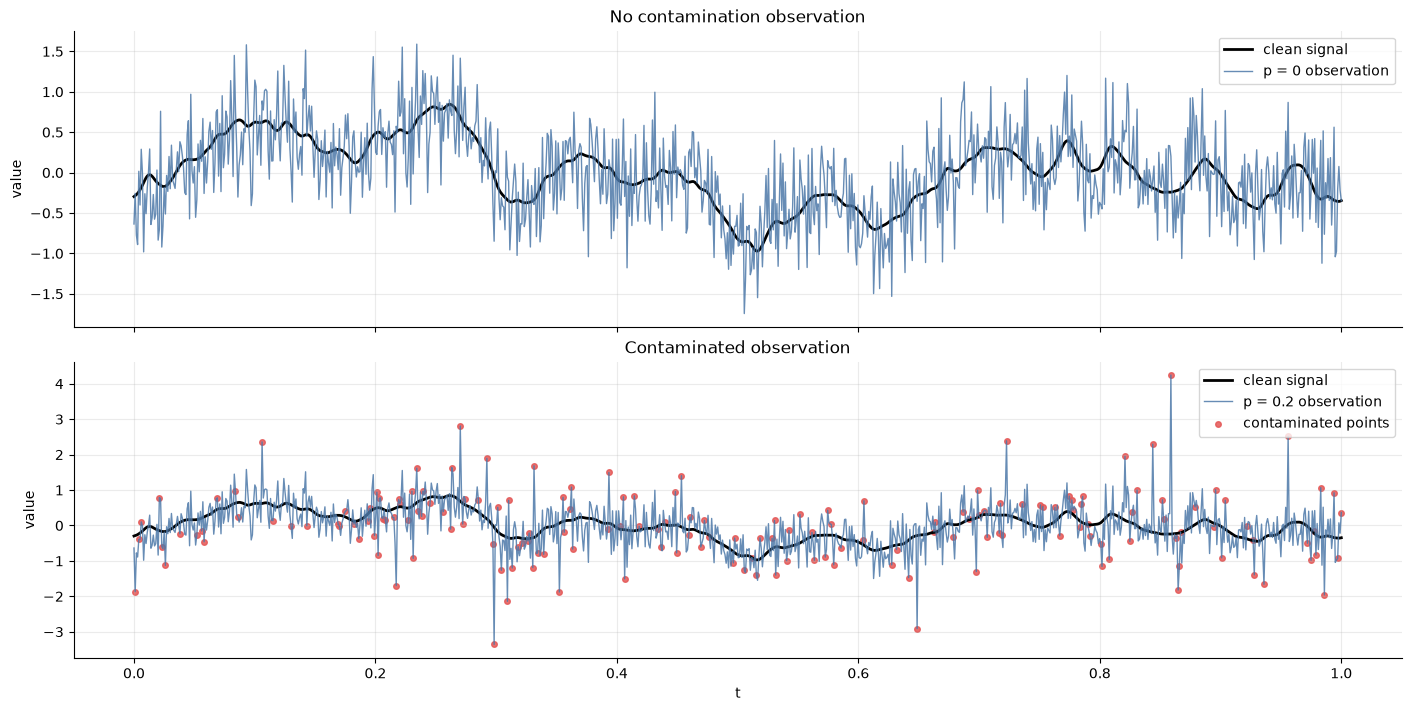

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, constrained_layout=True)

axes[0].plot(t, x_clean, color="black", linewidth=2.0, label="clean signal")
axes[0].plot(t, y_no_contamination, color="#4C78A8", linewidth=1.0, alpha=0.85, label="p = 0 observation")
axes[0].set_title("No contamination observation")
axes[0].set_ylabel("value")
axes[0].legend(loc="upper right")

mask = noise_info["contamination_mask"]
axes[1].plot(t, x_clean, color="black", linewidth=2.0, label="clean signal")
axes[1].plot(t, y_observed, color="#4C78A8", linewidth=1.0, alpha=0.85, label="p = 0.2 observation")
axes[1].scatter(
    t[mask],
    y_observed[mask],
    s=16,
    color="#E45756",
    alpha=0.85,
    label="contaminated points",
)
axes[1].set_title("Contaminated observation")
axes[1].set_xlabel("t")
axes[1].set_ylabel("value")
axes[1].legend(loc="upper right")

plt.show()

## Component error summary

The raw recursive and single-pass errors are identical to the source notebook. The standardized columns divide each error vector by its own stage- and family-specific RMS scale:

- exact complete-operator energy for linear errors;
- parametric-bootstrap RMS scale for robust errors.

Consequently, standardized RMSE values around one indicate errors consistent with the relevant noise/filter model. A standardized sup error is still a maximum of a correlated process and is not expected to be constant across stages.


In [9]:
def rmse(values):
    values = np.asarray(values, dtype=float)
    return np.sqrt(np.mean(values ** 2))


def summarize_error(error, case_name, stage_index, error_family, prefix):
    error = np.asarray(error, dtype=float)
    standardized_error = standardize_error(
        error,
        case_name,
        stage_index,
        error_family,
    )
    sup_error = np.max(np.abs(error))
    standardized_sup_error = np.max(np.abs(standardized_error))
    return {
        f"{prefix}_error_mean": np.mean(error),
        f"{prefix}_error_mae": np.mean(np.abs(error)),
        f"{prefix}_error_rmse": rmse(error),
        f"{prefix}_standardized_error_rmse": rmse(standardized_error),
        f"{prefix}_sup_error": sup_error,
        f"{prefix}_standardized_sup_error": standardized_sup_error,
        f"{prefix}_error_max_abs": sup_error,
        f"{prefix}_energy_scale": stage_error_scale(case_name, error_family, stage_index),
    }


def error_value_frame(case_name, stage_index, window_size, error_family, error):
    error = np.asarray(error, dtype=float)
    standardized_error = standardize_error(
        error,
        case_name,
        stage_index,
        error_family,
    )
    t_values = np.asarray(t, dtype=float)
    return pd.concat(
        [
            pd.DataFrame({
                "case": case_name,
                "stage": stage_index,
                "window_size": window_size,
                "error_family": error_family,
                "scale": "raw",
                "t": t_values,
                "error_value": error,
            }),
            pd.DataFrame({
                "case": case_name,
                "stage": stage_index,
                "window_size": window_size,
                "error_family": error_family,
                "scale": "energy standardized",
                "t": t_values,
                "error_value": standardized_error,
            }),
        ],
        ignore_index=True,
    )


def component_error_frames(case_name, real_result, calculated_result):
    rows = []
    value_frames = []
    for stage_index, window_size in enumerate(window_sizes, start=1):
        real_imf = real_result["imfs"][stage_index - 1]
        calculated_imf = calculated_result["imfs"][stage_index - 1]
        recursive_error = calculated_imf - real_imf
        rows.append({
            "case": case_name,
            "stage": stage_index,
            "window_size": window_size,
            **summarize_error(
                recursive_error,
                case_name,
                stage_index,
                "recursive",
                "recursive",
            ),
        })
        value_frames.append(
            error_value_frame(case_name, stage_index, window_size, "recursive", recursive_error)
        )
    return pd.DataFrame(rows), pd.concat(value_frames, ignore_index=True)


def linear_single_pass_error(real_signal, calculated_signal, window_size):
    return local_linear_filter(
        np.asarray(calculated_signal, dtype=float) - np.asarray(real_signal, dtype=float),
        window_size,
    )


def robust_single_pass_error(real_signal, calculated_signal, window_size):
    real_single_pass = local_robust_gd_filter(
        real_signal,
        window_size,
        H=H,
        grid=lookup_grid,
        max_iter=60,
        tol=1e-6,
        max_workers=DEFAULT_MAX_WORKERS,
    )
    calculated_single_pass = local_robust_gd_filter(
        calculated_signal,
        window_size,
        H=H,
        grid=lookup_grid,
        max_iter=60,
        tol=1e-6,
        max_workers=DEFAULT_MAX_WORKERS,
    )
    return calculated_single_pass - real_single_pass


def single_pass_error_frames(case_name, error_function):
    rows = []
    value_frames = []
    for stage_index, window_size in enumerate(window_sizes, start=1):
        single_pass_error = error_function(window_size)
        rows.append({
            "case": case_name,
            "stage": stage_index,
            "window_size": window_size,
            **summarize_error(
                single_pass_error,
                case_name,
                stage_index,
                "single_pass",
                "single_pass",
            ),
        })
        value_frames.append(
            error_value_frame(case_name, stage_index, window_size, "single_pass", single_pass_error)
        )
    return pd.DataFrame(rows), pd.concat(value_frames, ignore_index=True)


recursive_frames = [
    component_error_frames("no contamination / linear", real_linear, calculated_linear),
    component_error_frames("p = 0.2 / robust", real_robust, calculated_robust),
]

single_pass_frames = [
    single_pass_error_frames(
        "no contamination / linear",
        lambda window_size: linear_single_pass_error(x_clean, y_no_contamination, window_size),
    ),
    single_pass_error_frames(
        "p = 0.2 / robust",
        lambda window_size: robust_single_pass_error(x_clean, y_observed, window_size),
    ),
]

recursive_error_summary = pd.concat(
    [summary for summary, _ in recursive_frames],
    ignore_index=True,
)

single_pass_error_summary = pd.concat(
    [summary for summary, _ in single_pass_frames],
    ignore_index=True,
)

error_values = pd.concat(
    [values for _, values in recursive_frames + single_pass_frames],
    ignore_index=True,
)

error_summary = recursive_error_summary.merge(
    single_pass_error_summary,
    on=["case", "stage", "window_size"],
    validate="one_to_one",
)

error_summary[
    [
        "case",
        "stage",
        "window_size",
        "recursive_error_rmse",
        "recursive_energy_scale",
        "recursive_standardized_error_rmse",
        "single_pass_error_rmse",
        "single_pass_energy_scale",
        "single_pass_standardized_error_rmse",
        "recursive_sup_error",
        "recursive_standardized_sup_error",
        "single_pass_sup_error",
        "single_pass_standardized_sup_error",
    ]
]


,case,stage,window_size,recursive_error_rmse,recursive_energy_scale,recursive_standardized_error_rmse,single_pass_error_rmse,single_pass_energy_scale,single_pass_standardized_error_rmse,recursive_sup_error,recursive_standardized_sup_error,single_pass_sup_error,single_pass_standardized_sup_error
0,no contamination / linear,1,501,0.024080,0.024000,1.003321,0.024080,0.024000,1.003321,0.045424,1.892671,0.045424,1.892671
1,no contamination / linear,2,355,0.010586,0.011707,0.904233,0.028028,0.028523,0.982642,0.021843,1.865727,0.056920,1.995551
2,no contamination / linear,3,251,0.009927,0.011807,0.840794,0.032454,0.033942,0.956169,0.022369,1.894663,0.067865,1.999460
3,no contamination / linear,4,177,0.010339,0.013326,0.775861,0.037208,0.040454,0.919771,0.032164,2.413613,0.081466,2.013817
4,no contamination / linear,5,125,0.013394,0.015465,0.866080,0.042871,0.048197,0.889485,0.042606,2.754979,0.101197,2.099633
5,no contamination / linear,6,89,0.018929,0.017978,1.052871,0.051277,0.057218,0.896175,0.054099,3.009129,0.134738,2.354840
6,no contamination / linear,7,63,0.024960,0.021410,1.165794,0.064341,0.068179,0.943702,0.070330,3.284940,0.177959,2.610172
7,no contamination / linear,8,45,0.026529,0.025214,1.052167,0.079653,0.080959,0.983868,0.088463,3.508530,0.218581,2.699876
8,no contamination / linear,9,31,0.033173,0.031968,1.037707,0.099071,0.098124,1.009659,0.111825,3.498073,0.321398,3.275445
9,p = 0.2 / robust,1,501,0.034567,0.028267,1.222872,0.034567,0.028267,1.222872,0.064430,2.279339,0.064430,2.279339


## Standardization check

This compact table checks whether the observed RMSE is of the same size as its stage-specific denominator. Values need not equal one for a single realization; the goal is to remove the systematic low-pass-versus-band-pass scale mismatch.


In [10]:
calibration_rows = []
for case_name in error_summary["case"].unique():
    case_frame = error_summary.loc[error_summary["case"] == case_name]
    for error_family in ["recursive", "single_pass"]:
        column = f"{error_family}_standardized_error_rmse"
        values = case_frame.sort_values("stage")[column].to_numpy(dtype=float)
        tail = values[1:]
        calibration_rows.append({
            "case": case_name,
            "error_family": error_family,
            "stage_1_standardized_rmse": values[0],
            "mean_stages_2_9": np.mean(tail),
            "cv_stages_2_9": np.std(tail, ddof=1) / np.mean(tail),
            "mean_all_stages": np.mean(values),
        })

calibration_summary = pd.DataFrame(calibration_rows)
calibration_summary


,case,error_family,stage_1_standardized_rmse,mean_stages_2_9,cv_stages_2_9,mean_all_stages
0,no contamination / linear,recursive,1.003321,0.961938,0.139211,0.966537
1,no contamination / linear,single_pass,1.003321,0.947684,0.045960,0.953866
2,p = 0.2 / robust,recursive,1.222872,0.879998,0.076675,0.918095
3,p = 0.2 / robust,single_pass,1.222872,0.982245,0.082009,1.008981


## Comparison grids

Each row is one IMF stage. The fourth column now shows the recursive error divided by its stage-specific RMS scale. Within each grid, both IMF columns share one range, raw errors share one range, and standardized errors share one range.


In [11]:
def min_max_limits(*arrays, pad_fraction=0.06, min_span=1e-6):
    values = np.concatenate([np.ravel(np.asarray(array, dtype=float)) for array in arrays])
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return (-1.0, 1.0)

    low = float(np.min(values))
    high = float(np.max(values))
    if high - low < min_span:
        center = 0.5 * (low + high)
        return (center - 0.5, center + 0.5)

    pad = pad_fraction * (high - low)
    return (low - pad, high + pad)


def comparison_column_limits(real_result, calculated_result, case_name):
    real_imfs = np.asarray(real_result["imfs"], dtype=float)
    calculated_imfs = np.asarray(calculated_result["imfs"], dtype=float)
    errors = calculated_imfs - real_imfs
    standardized_errors = np.vstack([
        standardize_error(error, case_name, stage_index, "recursive")
        for stage_index, error in enumerate(errors, start=1)
    ])

    return {
        "imf": min_max_limits(real_imfs, calculated_imfs),
        "error": min_max_limits(errors),
        "standardized_error": min_max_limits(standardized_errors),
    }


def plot_imf_comparison_grid(real_result, calculated_result, calculated_label, title, case_name):
    n_stages = len(window_sizes)
    limits = comparison_column_limits(real_result, calculated_result, case_name)

    fig, axes = plt.subplots(
        n_stages,
        4,
        figsize=(18, 2.25 * n_stages),
        sharex=True,
        constrained_layout=True,
    )

    column_titles = ["Real IMF", calculated_label, "Recursive error", "Recursive error / stage RMS scale"]
    for col, column_title in enumerate(column_titles):
        axes[0, col].set_title(column_title, fontsize=12)

    for row, window_size in enumerate(window_sizes):
        real_imf = real_result["imfs"][row]
        calculated_imf = calculated_result["imfs"][row]
        error = calculated_imf - real_imf
        scaled_error = standardize_error(error, case_name, row + 1, "recursive")

        axes[row, 0].plot(t, real_imf, color="black", linewidth=1.25)
        axes[row, 0].set_ylim(*limits["imf"])
        axes[row, 0].set_ylabel(f"IMF {row + 1}\nwindow={window_size}")

        axes[row, 1].plot(t, calculated_imf, color="#4C78A8", linewidth=1.1)
        axes[row, 1].set_ylim(*limits["imf"])

        axes[row, 2].axhline(0.0, color="#666666", linewidth=0.8, alpha=0.65)
        axes[row, 2].plot(t, error, color="#E45756", linewidth=1.0)
        axes[row, 2].set_ylim(*limits["error"])

        axes[row, 3].axhline(0.0, color="#666666", linewidth=0.8, alpha=0.65)
        axes[row, 3].plot(t, scaled_error, color="#54A24B", linewidth=1.0)
        axes[row, 3].set_ylim(*limits["standardized_error"])

        for col in range(4):
            axes[row, col].tick_params(axis="both", labelsize=8)
            axes[row, col].margins(x=0.0)

    for ax in axes[-1, :]:
        ax.set_xlabel("t")

    fig.suptitle(title, fontsize=15)
    return fig, axes

def fit_line(x, y):
    slope, intercept = np.polyfit(np.asarray(x, dtype=float), np.asarray(y, dtype=float), deg=1)
    return float(slope), float(intercept)


def plot_error_trend(case_name, title, min_stage=1):
    case_df = error_summary.loc[
        (error_summary["case"] == case_name)
        & (error_summary["stage"] >= min_stage)
    ].copy()
    if case_df.empty:
        raise ValueError(f"No rows found for case: {case_name} with min_stage={min_stage}")

    x = case_df["stage"].to_numpy(dtype=float)
    metrics = [
        ("recursive_error_rmse", "Recursive IMF RMSE(error)", "#E45756", "raw_recursive"),
        ("single_pass_error_rmse", "Single-pass RMSE(error)", "#F58518", "raw_single_pass"),
        ("recursive_standardized_error_rmse", "Recursive IMF energy-standardized RMSE", "#54A24B", "standardized_recursive"),
        ("single_pass_standardized_error_rmse", "Single-pass energy-standardized RMSE", "#72B7B2", "standardized_single_pass"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 7.5), sharex=True, constrained_layout=True)
    axes = np.ravel(axes)
    coefficient_rows = []
    plot_rows = []
    y_limit_values = {limit_group: [] for *_, limit_group in metrics}

    for column, label, color, limit_group in metrics:
        y = case_df[column].to_numpy(dtype=float)
        slope, intercept = fit_line(x, y)
        y_limit_values[limit_group].append(y)
        plot_rows.append((column, label, color, limit_group, y))

        coefficient_rows.append({
            "case": case_name,
            "min_stage": min_stage,
            "metric": label,
            "slope": slope,
            "intercept": intercept,
        })

    y_limits = {
        limit_group: min_max_limits(*values)
        for limit_group, values in y_limit_values.items()
    }

    for ax, (column, label, color, limit_group, y) in zip(axes, plot_rows):
        ax.plot(x, y, marker="o", color=color, linewidth=1.4, label=label)
        ax.set_title(label)
        ax.set_xlabel("IMF count k")
        ax.set_ylabel("dimensionless RMSE" if "standardized" in column else "RMSE over t")
        ax.set_xticks(case_df["stage"])
        ax.set_ylim(*y_limits[limit_group])
        ax.legend(loc="best", fontsize=8)

    fig.suptitle(title, fontsize=14)
    coefficients = pd.DataFrame(coefficient_rows)
    display(coefficients)
    return fig, axes, coefficients


def plot_sup_error_trend(case_name, title, min_stage=1):
    case_df = error_summary.loc[
        (error_summary["case"] == case_name)
        & (error_summary["stage"] >= min_stage)
    ].copy()
    if case_df.empty:
        raise ValueError(f"No rows found for case: {case_name} with min_stage={min_stage}")

    x = case_df["stage"].to_numpy(dtype=float)
    metrics = [
        ("recursive_sup_error", "Recursive IMF sup(error)", "#E45756", "raw_recursive"),
        ("single_pass_sup_error", "Single-pass sup(error)", "#F58518", "raw_single_pass"),
        ("recursive_standardized_sup_error", "Recursive IMF sup(error / RMS scale)", "#54A24B", "standardized_recursive"),
        ("single_pass_standardized_sup_error", "Single-pass sup(error / RMS scale)", "#72B7B2", "standardized_single_pass"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 7.5), sharex=True, constrained_layout=True)
    axes = np.ravel(axes)
    coefficient_rows = []
    plot_rows = []
    y_limit_values = {limit_group: [] for *_, limit_group in metrics}

    for column, label, color, limit_group in metrics:
        y = case_df[column].to_numpy(dtype=float)
        slope, intercept = fit_line(x, y)
        y_limit_values[limit_group].append(y)
        plot_rows.append((column, label, color, limit_group, y))

        coefficient_rows.append({
            "case": case_name,
            "min_stage": min_stage,
            "metric": label,
            "slope": slope,
            "intercept": intercept,
        })

    y_limits = {
        limit_group: min_max_limits(*values)
        for limit_group, values in y_limit_values.items()
    }

    for ax, (column, label, color, limit_group, y) in zip(axes, plot_rows):
        ax.plot(x, y, marker="o", color=color, linewidth=1.4, label=label)
        ax.set_title(label)
        ax.set_xlabel("IMF count k")
        ax.set_ylabel("dimensionless sup" if "standardized" in column else "sup_t |error|")
        ax.set_xticks(case_df["stage"])
        ax.set_ylim(*y_limits[limit_group])
        ax.legend(loc="best", fontsize=8)

    fig.suptitle(title, fontsize=14)
    coefficients = pd.DataFrame(coefficient_rows)
    display(coefficients)
    return fig, axes, coefficients


def plot_error_boxplots(case_name, title, min_stage=1):
    case_values = error_values.loc[
        (error_values["case"] == case_name)
        & (error_values["stage"] >= min_stage)
    ].copy()
    if case_values.empty:
        raise ValueError(f"No rows found for case: {case_name} with min_stage={min_stage}")

    panels = [
        ("recursive", "raw", "Recursive IMF error", "#E45756"),
        ("single_pass", "raw", "Single-pass error", "#F58518"),
        ("recursive", "energy standardized", "Recursive IMF energy-standardized error", "#54A24B"),
        ("single_pass", "energy standardized", "Single-pass energy-standardized error", "#72B7B2"),
    ]
    stages = np.sort(case_values["stage"].unique())
    y_limits = {
        scale: min_max_limits(case_values.loc[case_values["scale"] == scale, "error_value"])
        for scale in case_values["scale"].unique()
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 7.5), sharex=True, constrained_layout=True)
    axes = np.ravel(axes)

    for ax, (error_family, scale, label, color) in zip(axes, panels):
        panel = case_values.loc[
            (case_values["error_family"] == error_family)
            & (case_values["scale"] == scale)
        ]
        data = [
            panel.loc[panel["stage"] == stage, "error_value"].to_numpy(dtype=float)
            for stage in stages
        ]
        boxplot = ax.boxplot(
            data,
            positions=stages,
            widths=0.55,
            patch_artist=True,
            tick_labels=[str(int(stage)) for stage in stages],
            flierprops={"marker": ".", "markersize": 2.0, "alpha": 0.25},
            medianprops={"color": "black", "linewidth": 1.1},
        )
        for patch in boxplot["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.35)
            patch.set_edgecolor(color)
        for whisker in boxplot["whiskers"]:
            whisker.set_color(color)
        for cap in boxplot["caps"]:
            cap.set_color(color)

        ax.axhline(0.0, color="#666666", linewidth=0.8, alpha=0.65)
        ax.set_title(label)
        ax.set_xlabel("IMF count k")
        ax.set_ylabel("signed error" if scale == "raw" else "standardized signed error")
        ax.set_ylim(*y_limits[scale])

    fig.suptitle(title, fontsize=14)
    return fig, axes


### No contamination: linear IMF

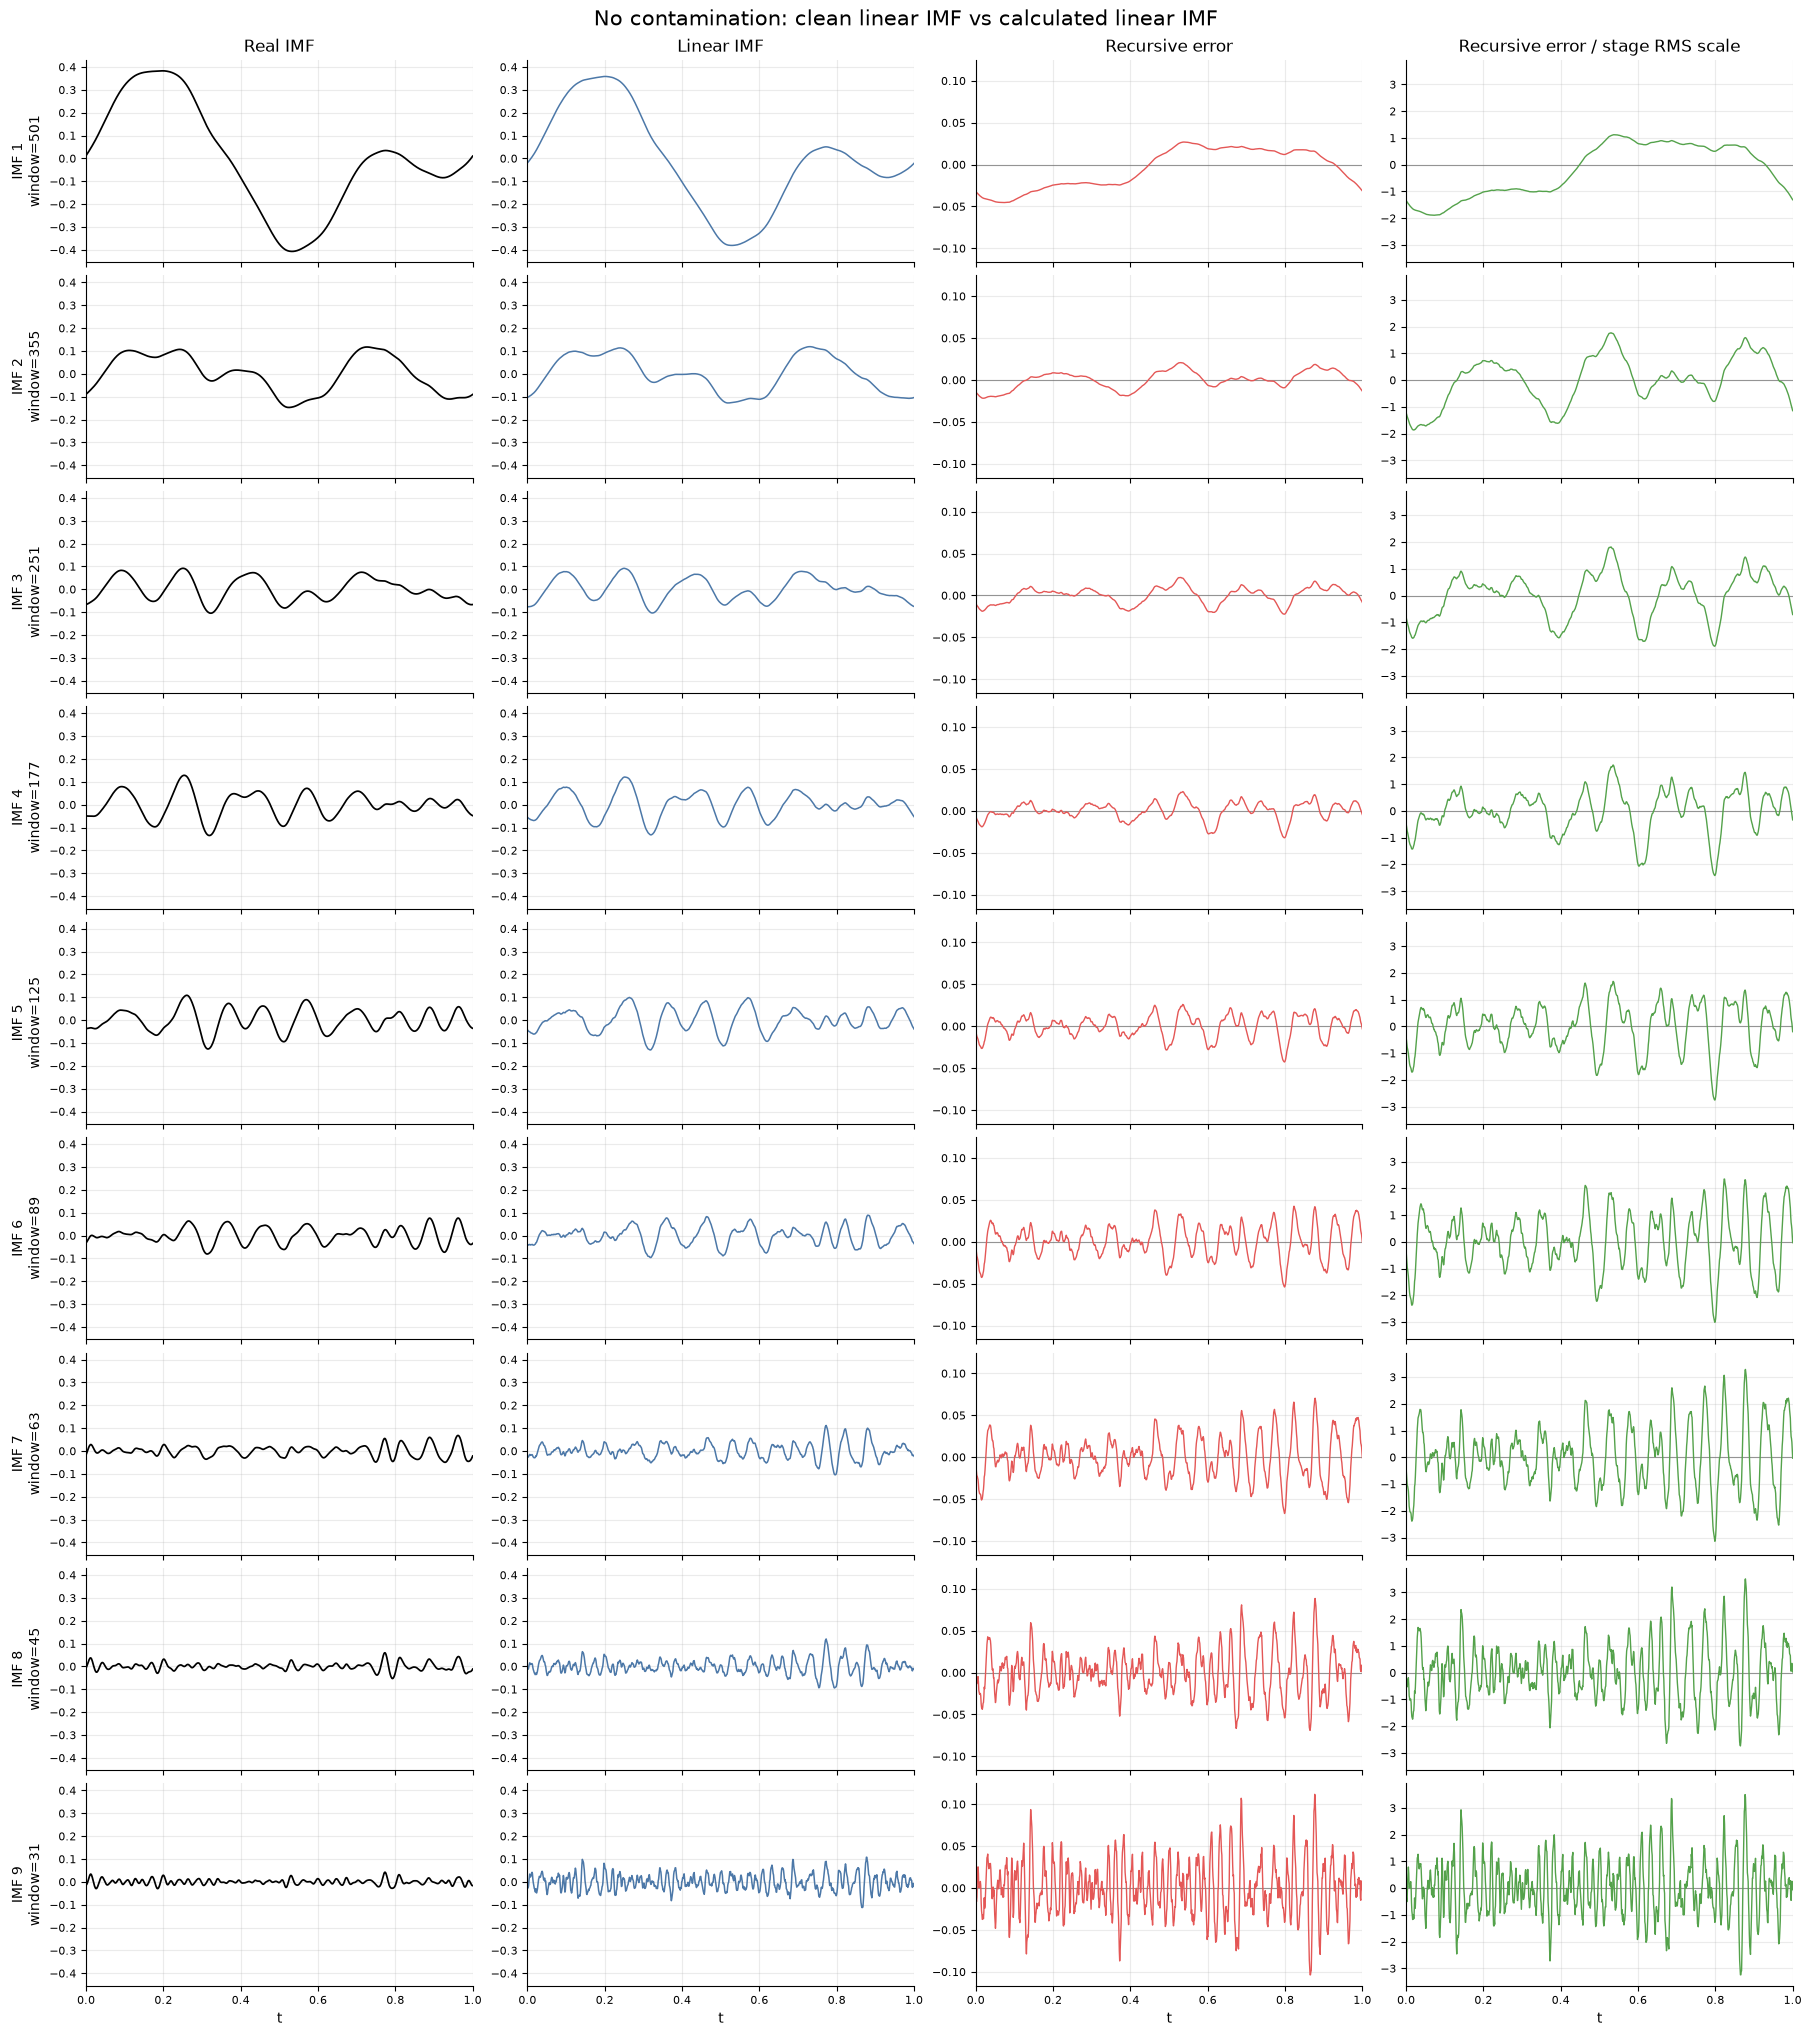

In [12]:
plot_imf_comparison_grid(
    real_linear,
    calculated_linear,
    calculated_label="Linear IMF",
    title="No contamination: clean linear IMF vs calculated linear IMF",
    case_name="no contamination / linear",
)
plt.show()

### No contamination: energy-standardized error trends

The linear denominators are exact finite-sample standard deviations of the implemented periodic operators.


,case,min_stage,metric,slope,intercept
0,no contamination / linear,1,Recursive IMF RMSE(error),0.002048,0.008864
1,no contamination / linear,1,Single-pass RMSE(error),0.008878,0.006608
2,no contamination / linear,1,Recursive IMF energy-standardized RMSE,0.025139,0.840840
3,no contamination / linear,1,Single-pass energy-standardized RMSE,-0.000325,0.955491


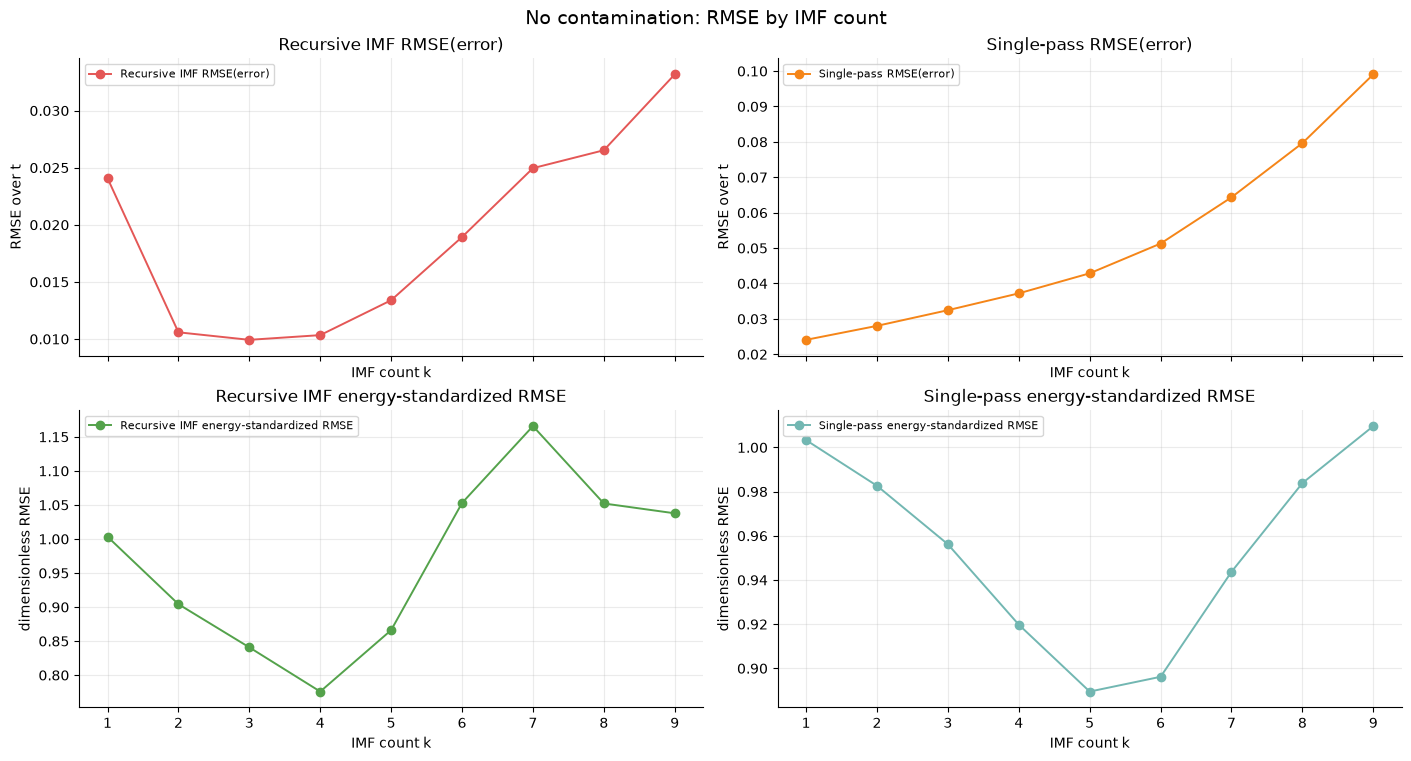

In [13]:
plot_error_trend(
    case_name="no contamination / linear",
    title="No contamination: RMSE by IMF count",
)
plt.show()

### No contamination: sup-error trends and boxplots

Standardized panels divide by exact linear RMS scales. Sup errors need not be flat because an RMS scale does not adjust for the changing number of effective extrema.


,case,min_stage,metric,slope,intercept
0,no contamination / linear,1,Recursive IMF sup(error),0.009722,0.005737
1,no contamination / linear,1,Single-pass sup(error),0.031039,-0.021245
2,no contamination / linear,1,Recursive IMF sup(error / RMS scale),0.245435,1.453084
3,no contamination / linear,1,Single-pass sup(error / RMS scale),0.153442,1.559619


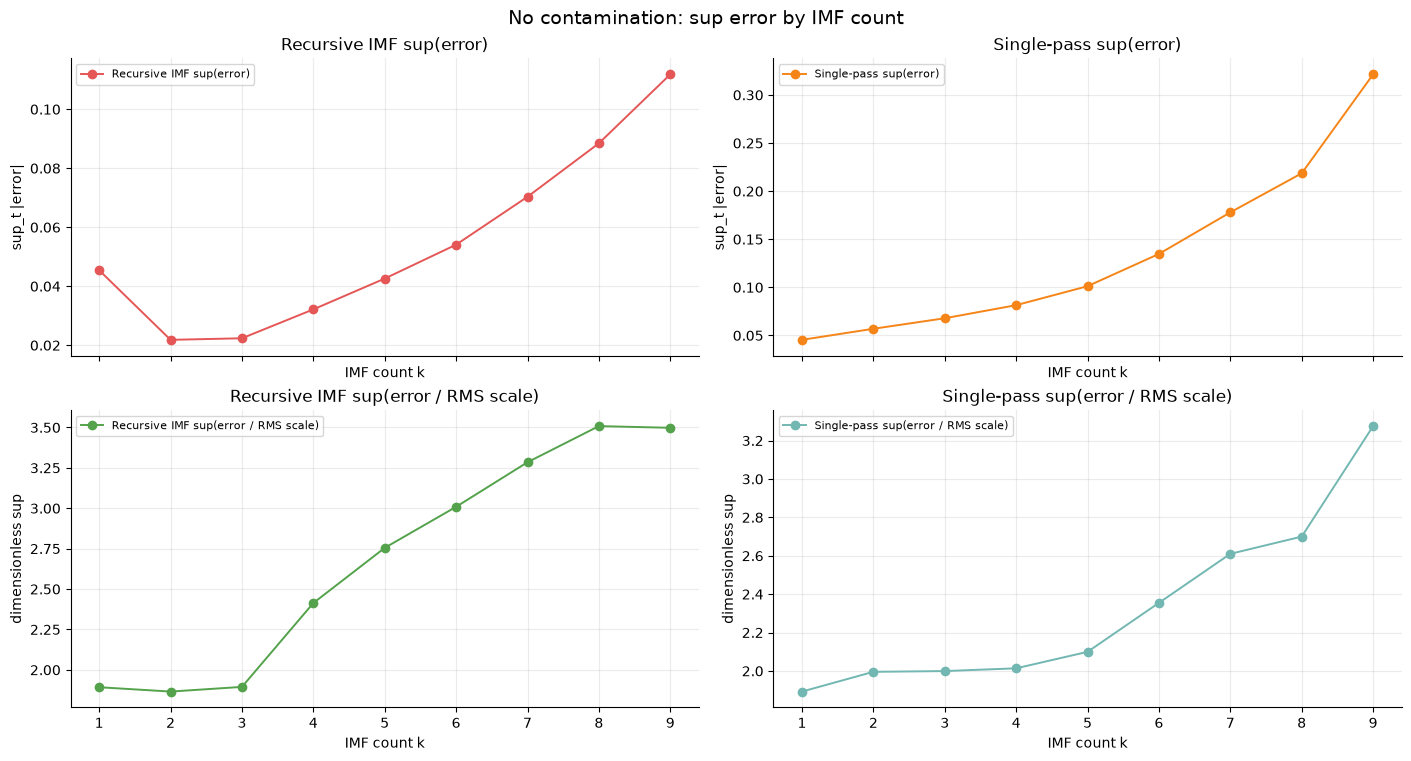

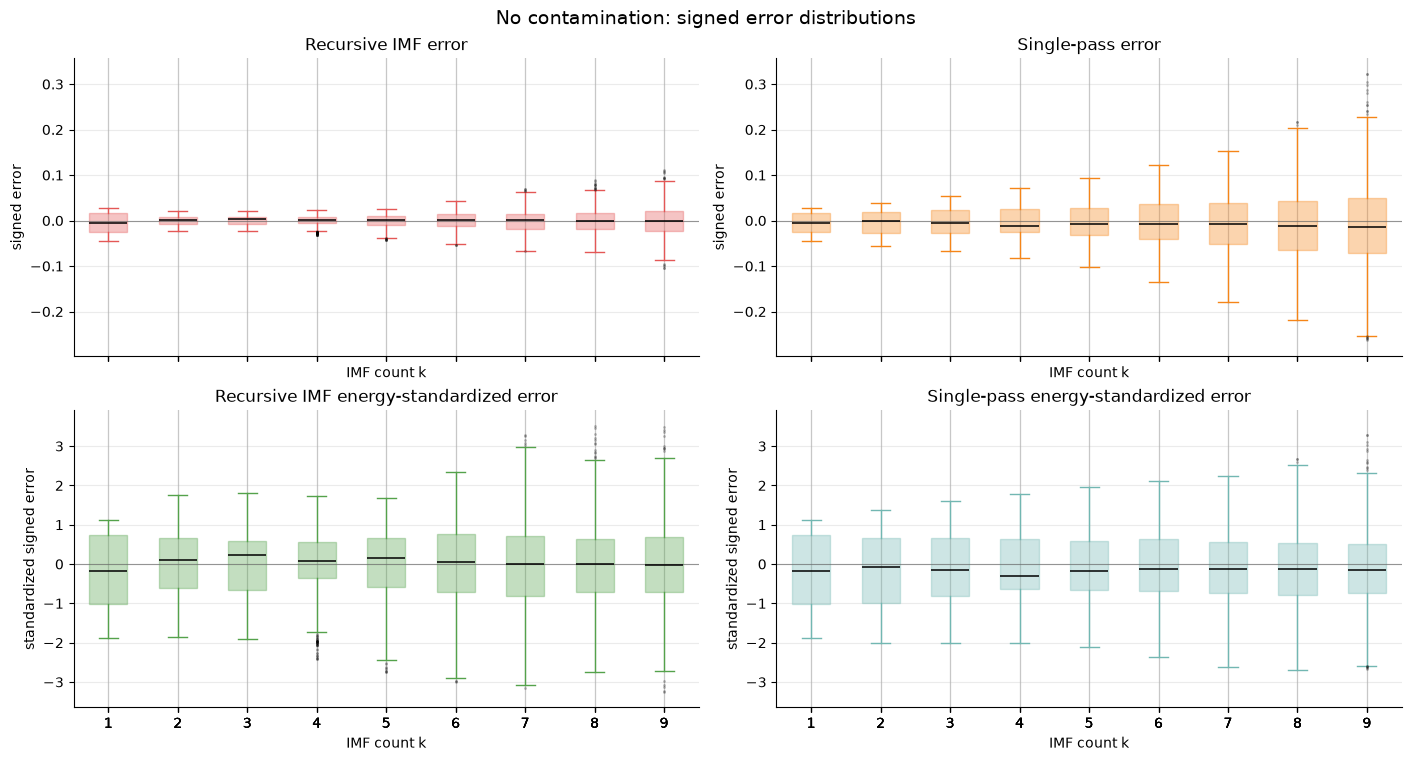

In [14]:
plot_sup_error_trend(
    case_name="no contamination / linear",
    title="No contamination: sup error by IMF count",
)
plt.show()

plot_error_boxplots(
    case_name="no contamination / linear",
    title="No contamination: signed error distributions",
)
plt.show()


### With contamination: robust IMF

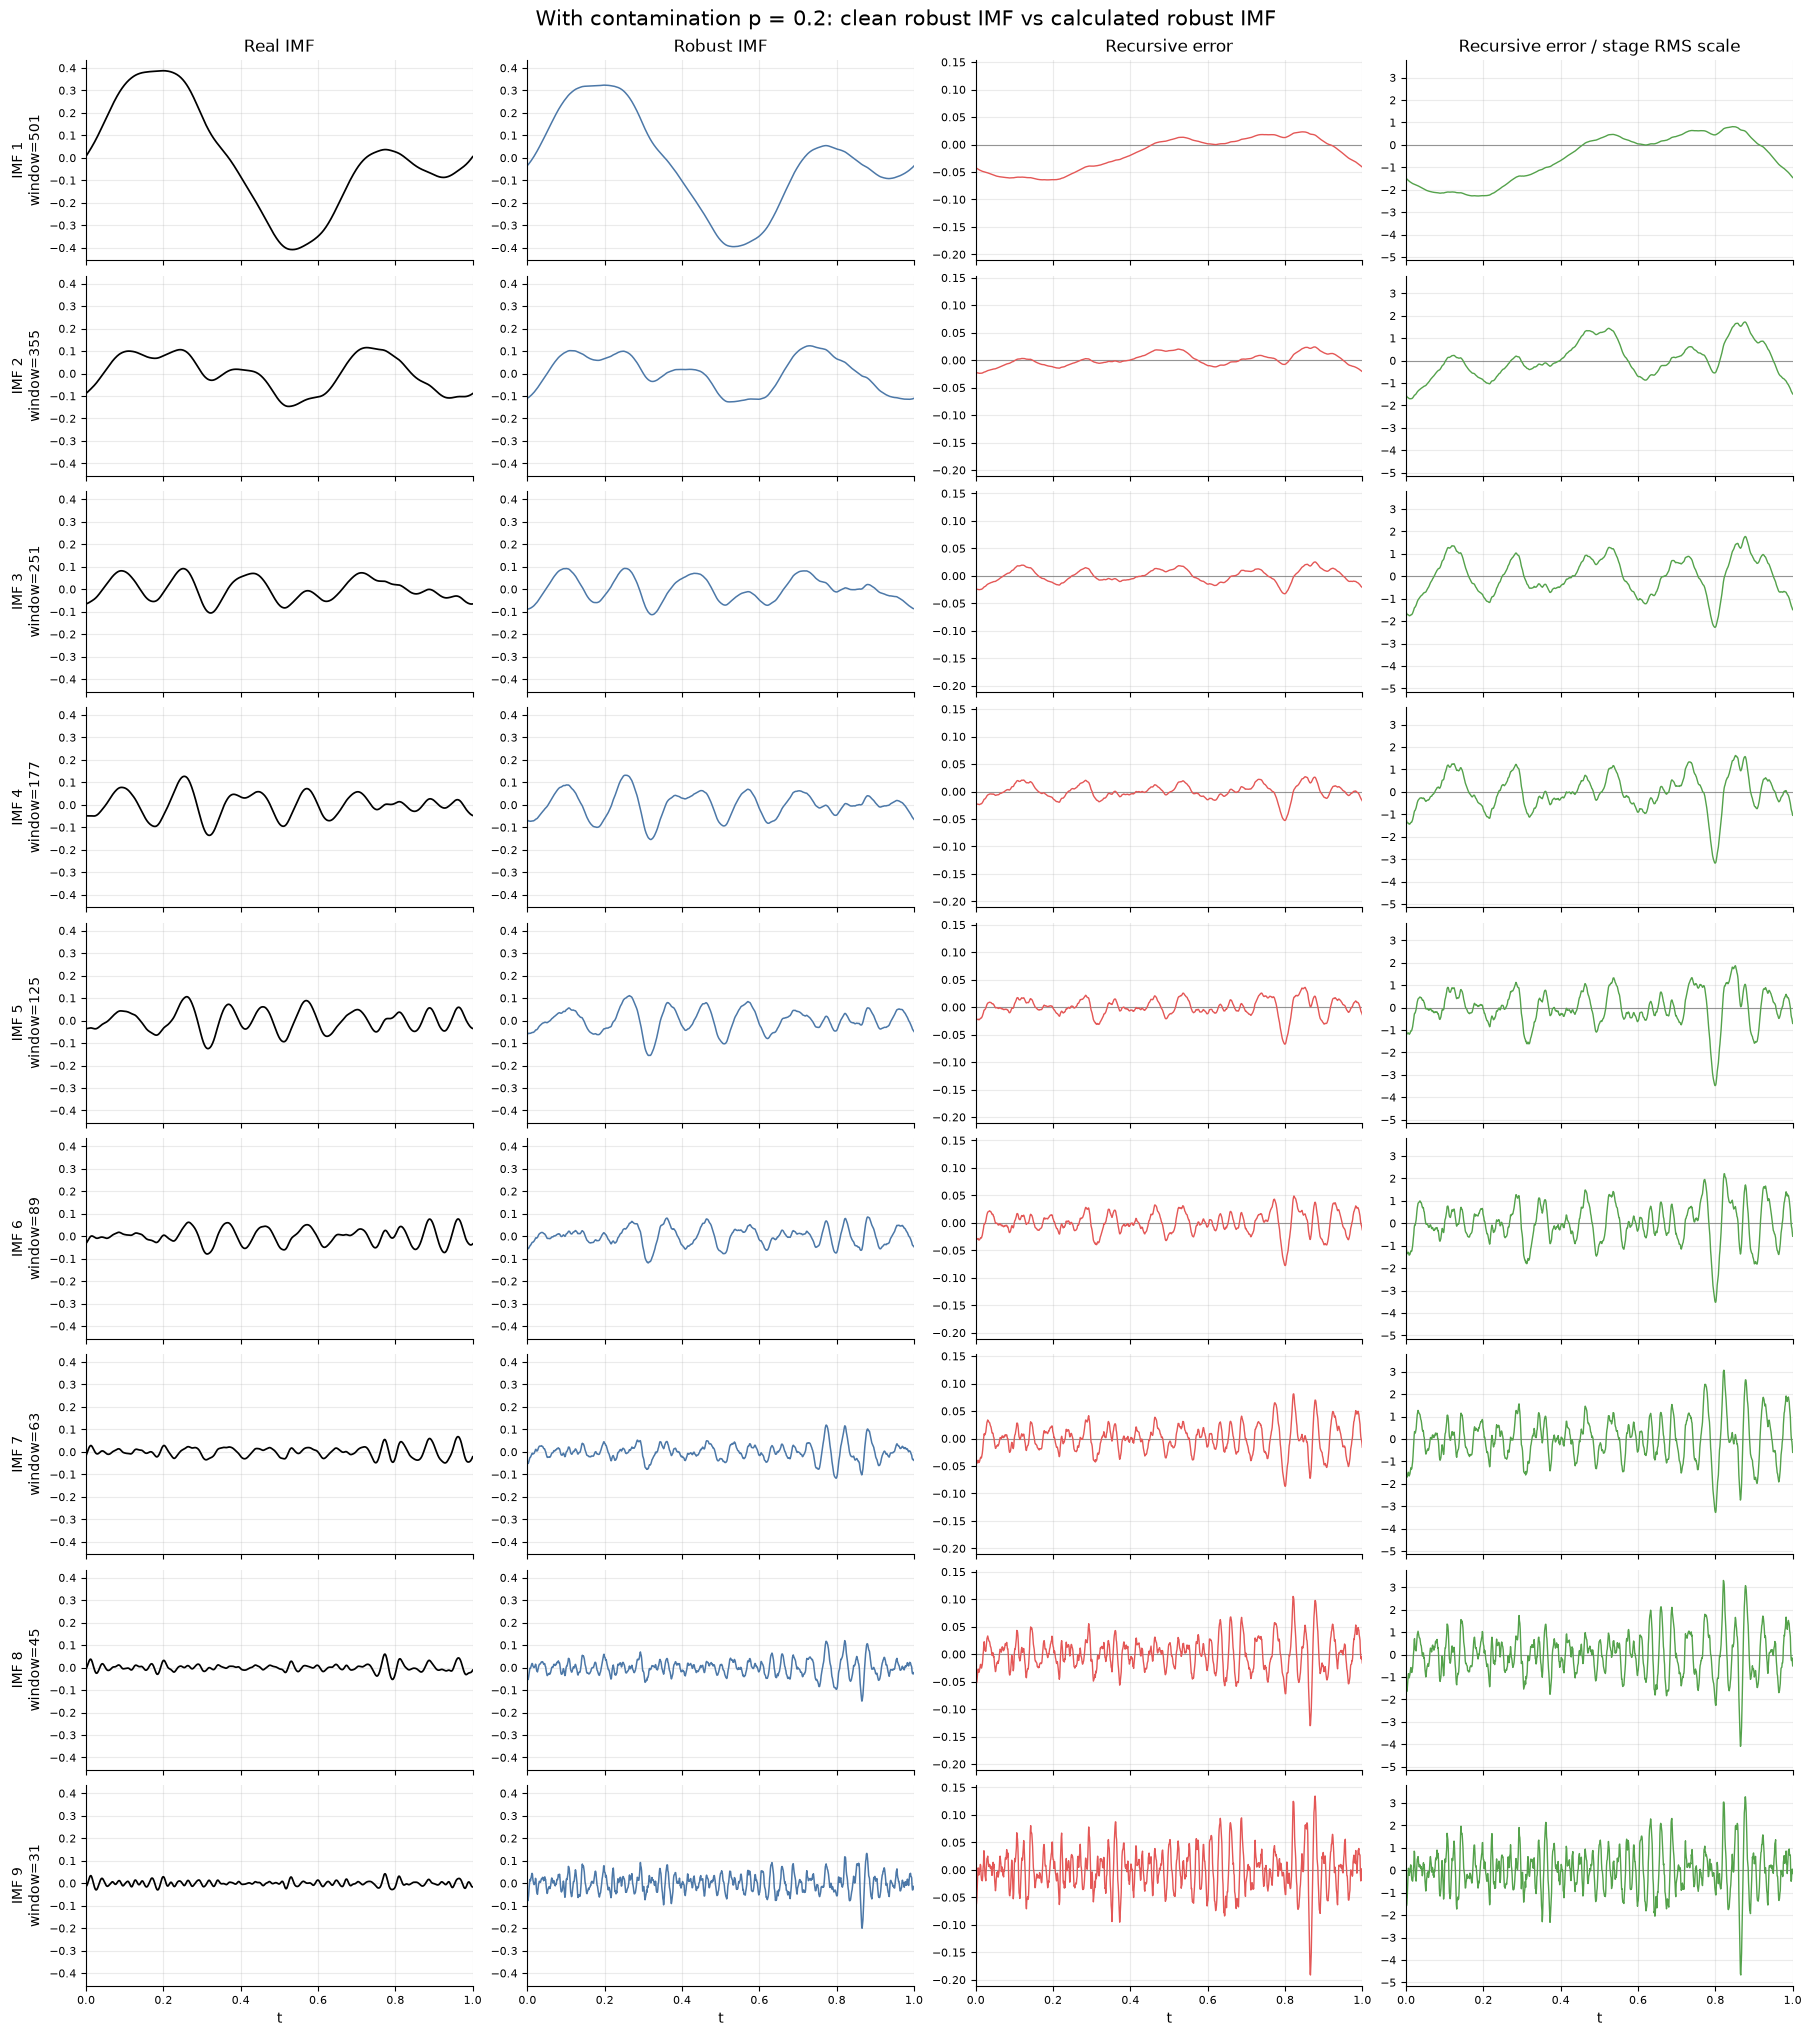

In [15]:
plot_imf_comparison_grid(
    real_robust,
    calculated_robust,
    calculated_label="Robust IMF",
    title="With contamination p = 0.2: clean robust IMF vs calculated robust IMF",
    case_name="p = 0.2 / robust",
)
plt.show()

### With contamination: energy-standardized error trends

The robust denominators are estimated from the parametric bootstrap above using the same contamination model and clean-fit reference.


,case,min_stage,metric,slope,intercept
0,p = 0.2 / robust,1,Recursive IMF RMSE(error),0.001771,0.013530
1,p = 0.2 / robust,1,Single-pass RMSE(error),0.009346,0.016147
2,p = 0.2 / robust,1,Recursive IMF energy-standardized RMSE,-0.006200,0.949097
3,p = 0.2 / robust,1,Single-pass energy-standardized RMSE,-0.036267,1.190318


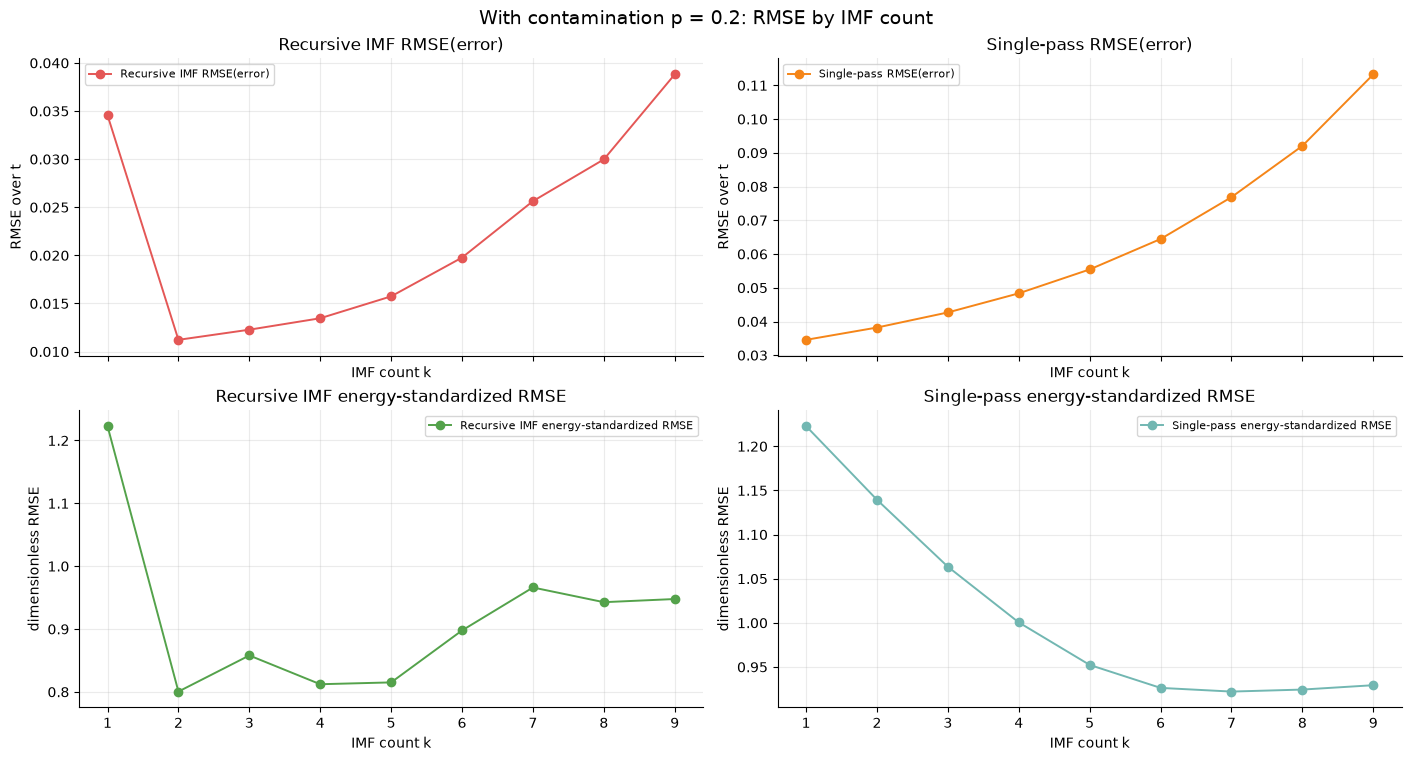

In [16]:
plot_error_trend(
    case_name="p = 0.2 / robust",
    title="With contamination p = 0.2: RMSE by IMF count",
)
plt.show()

### With contamination: sup-error trends and boxplots

Standardized panels divide by robust bootstrap RMS scales. These are pointwise/RMSE calibrations, not simultaneous sup-error calibrations.


,case,min_stage,metric,slope,intercept
0,p = 0.2 / robust,1,Recursive IMF sup(error),0.015981,0.000872
1,p = 0.2 / robust,1,Single-pass sup(error),0.038613,-0.024180
2,p = 0.2 / robust,1,Recursive IMF sup(error / RMS scale),0.317018,1.581470
3,p = 0.2 / robust,1,Single-pass sup(error / RMS scale),0.129968,1.789189


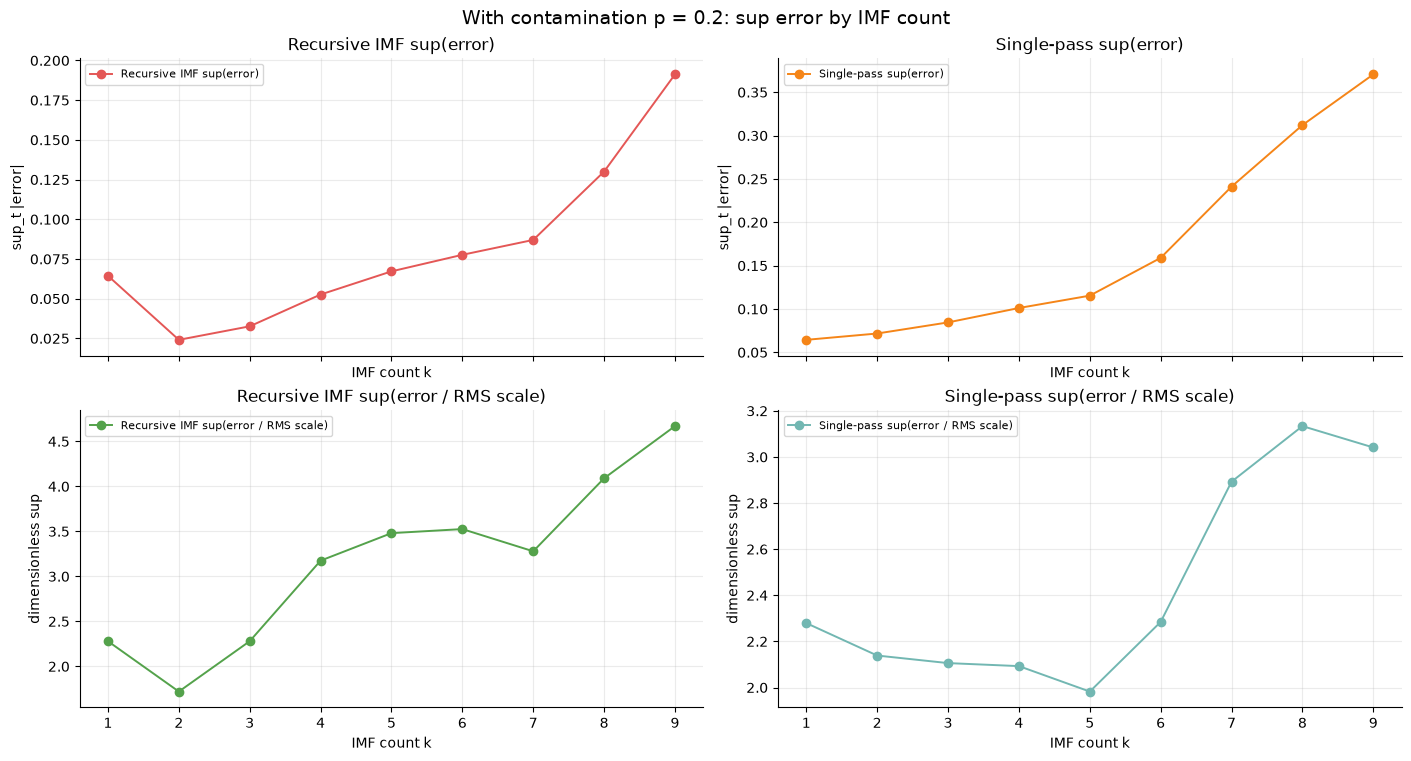

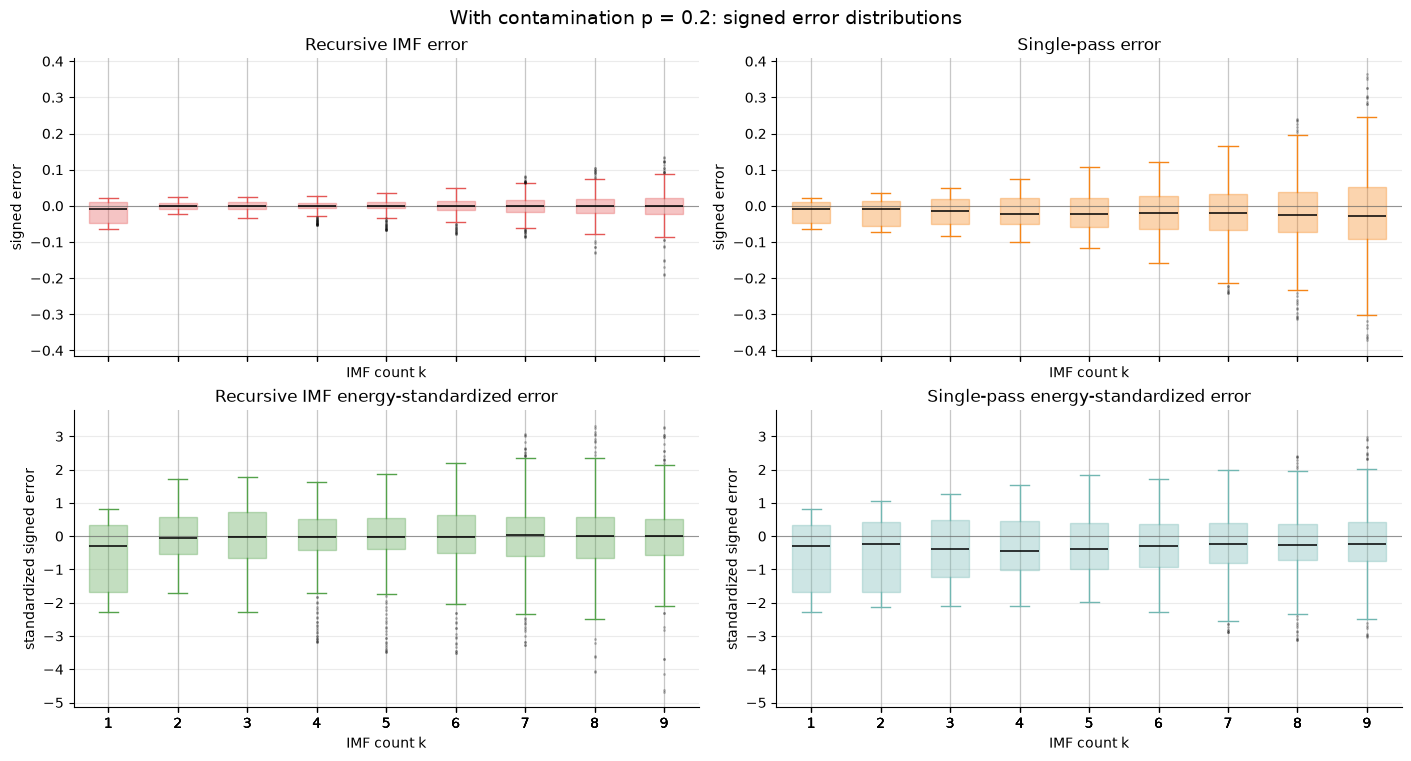

In [17]:
plot_sup_error_trend(
    case_name="p = 0.2 / robust",
    title="With contamination p = 0.2: sup error by IMF count",
)
plt.show()

plot_error_boxplots(
    case_name="p = 0.2 / robust",
    title="With contamination p = 0.2: signed error distributions",
)
plt.show()


## Interpretation

- The exact linear energy scaling removes the artificial requirement that the low-pass first component and later band-pass components share one hidden constant.
- The robust bootstrap performs the analogous calibration for this nonlinear experiment and its stated observation model.
- Standardized RMSE values fluctuate around one because only one noise realization is displayed; exact equality is neither expected nor imposed.
- Standardized sup errors remain stage-dependent because correlation length and effective multiplicity change with the window.

This notebook changes only the diagnostic normalization. Signal generation, observation generation, filters, recursion, optimization, and raw component errors match the source notebook.
